In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd

# 날씨 데이터 (숫자 인코딩)
# 0 : 맑음, 1 : 흐림, 2 : 비
# 0 : 낮음/약함, 1 : 높음/강함
# 데이터프레임 생성

df = pd.DataFrame({
    "날씨": [0, 0, 1, 2],
    "습도": [1, 0, 1, 1],
    "바람": [0, 0, 1, 0],
    "테니스": [0, 1, 1, 0]
})

model = DecisionTreeClassifier(random_state=42)

x = df[["날씨", "습도", "바람"]]
y = df["테니스"]

model.fit(x,y)

# 예측
# 날씨 : 맑음
# 습도 : 높음
# 바람 : 약함

print(model.predict([[1,0,1]]))

[1]


c:\miniconda3\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


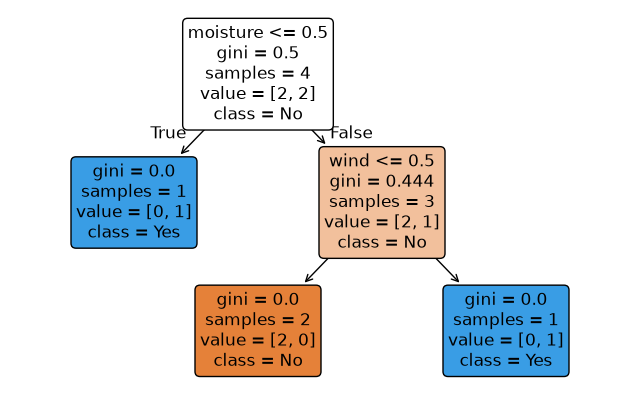

In [16]:
# 🌳 트리 시각화
# 시각화
plt.figure(figsize=(8, 5))

plot_tree(
    model,
    # feature_names = X.columns,      # 컬럼명 표시
    feature_names = ["weather", "moisture", "wind"],
    class_names=["No", "Yes"],    # 0,1 이름 변경
    filled=True,                  # 색상
    rounded=True,                 # 둥근 모서리
    fontsize=12
)

plt.show()

# 내부 동작 순서
# 트리는 내부적으로 이렇게 계산

# 날씨로 나누면 얼마나 잘 분리되지?  =>  습도로 나누면?  =>  바람으로 나누면?

# gini 계수 : 결정트리에서 데이터가 얼마나 섞여 있는지 (불순도)를 측정하는 지표 , 클래스 비율 제곱의 합을 1에서 뺀 값
# 여러 클래스가 섞여 있으면 지니 값 증가, 하나의 클래스만 존재하면 지니 값 감소 => 결정 트리는 불순도(Gini)가 가장 많이 감소하는 변수를 루트로 선택

# 아래의 결정트리 이미지레서 보면 아까 찾아본 model.predict([[1,0,1]]) 이걸 기준으로 보면 습도가 moisture인데 0.5 이하는 true인데 
# 내가 궁금한 값의 습도는 0으로 true이기에 왼쪽으로 가서 yes에 해당함. 
# => 만약 0.5 이상의 값 이었으면 False로 가고 그 다음 바람이나 그런것들로 분류함

[1]


c:\miniconda3\envs\env_ds\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


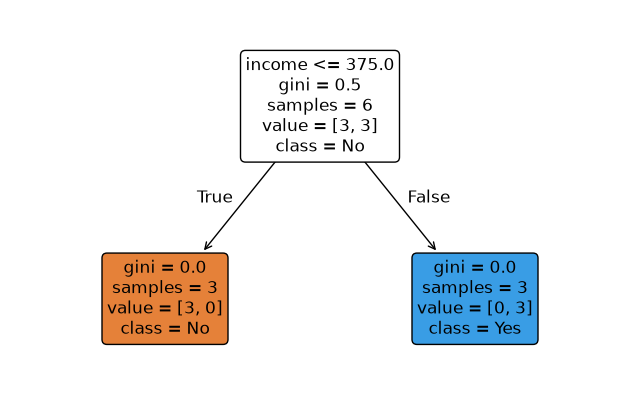

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import pandas as pd

df = pd.DataFrame({

    "income":[
        200,250,300,350,
        400,450,500,550
    ],

    "debt":[
        300,280,250,220,
        180,150,120,100
    ],

    "loan":[
        0,0,0,0,
        1,1,1,1
    ]

})

x = df[["income","debt"]]
y = df["loan"]

train_x,test_x,train_y,test_y= train_test_split(
    x,y,test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(train_x,train_y)

pred = model.predict(train_x)


print(model.predict([[420,170]]))


# 시각화

plt.figure(figsize=(8, 5))

plot_tree(
    model,
    # feature_names = X.columns,      # 컬럼명 표시
    feature_names = ["income", "debt"],
    class_names=["No", "Yes"],    # 0,1 이름 변경
    filled=True,                  # 색상
    rounded=True,                 # 둥근 모서리
    fontsize=12
)

plt.show()